In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

In [4]:
x = loadmat('data/x')['x'].ravel()
H = loadmat('data/H')['H']
G = loadmat('data/G')['G']
print(f"x shape: {x.shape}, H shape: {H.shape}, G shape: {G.shape}")


x shape: (8100,), H shape: (16200, 8100), G shape: (16200, 8100)


y shape: (16200,)


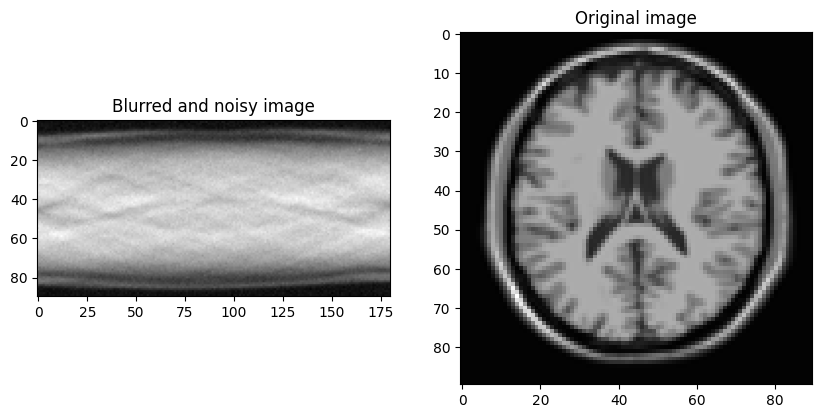

(8100,)


In [ ]:
sigma = 1
y = H @ x + sigma * np.random.standard_normal(H.shape[0]) 
print(f"y shape: {y.shape}")
Y = y.reshape((90,180),order='F')
X = x.reshape((90,90),order='F')

plt.figure(figsize=(10,7))
plt.subplot(1,2,2)
plt.imshow(X, cmap='gray')
plt.title("Original image")
plt.subplot(1,2,1)
plt.imshow(Y, cmap='gray')
plt.title("Blurred"" and noisy image")
plt.show()


### Gradient de f
$$x \in \R^N, G \in \R^{2N \times N}$$
$$f(x) = \frac{1}{2}||Hx - y||^2 + \lambda r(x)$$
$$r(x) = \sum_{n=1}^{2N}{\psi([Gx]^{(n)})} = \mathbb{1}^T\psi(Gx)$$
$$\psi(u) = \sqrt{1+\frac{u^2}{\delta^2}} $$

D'abord :
$$\nabla f(x) =  H^T (Hx-y) + \lambda \nabla r(x)  $$
puis on calcul la dérivée de psi :
$$\psi '(u) = \frac{u}{\delta^2 \sqrt{1+\frac{u^2}{\delta^2}}} = \frac{u}{\delta \sqrt{\delta^2+u^2}} = \frac{1}{\delta \sqrt{\frac{\delta^2}{u^2}+1}} $$
puis on compose :

$$\nabla_{x}r(x) = G^T\psi '(Gx) = G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N}$$
Et enfin : 

$$\nabla f(x) =  H^T (Hx-y) + \lambda G^T[\frac{1}{\delta \sqrt{\frac{\delta^2}{[Gx]_{(n)}^2}+1}}]_{1<n<2N} =  H^T (Hx-y) + \lambda G^T[\frac{[Gx]_{(n)}}{\delta^2 \sqrt{\frac{[Gx]_{(n)}^2}{\delta^2}+1}}]_{1<n<2N}  $$

In [ ]:
def f(x, H, y ,lambda_, G, delta):
    return 0.5 * np.linalg.norm(H @ x - y)**2 + lambda_ * np.sum(np.sqrt(1 -((G @ x)**2 / delta**2)))
def grad_f(x, H, y ,lambda_, G, delta):
    return H.T @ (H @ x - y) - lambda_ * G.T @ (1 / (delta * np.sqrt((delta/ (G @ x))**2 - 1)))


### Lipschitz constant

Le premier terme du gradient a une constante de lipschitz évidente : $||H||^2$.
Calculons la hésienne de r pour le second terme.
Posons 
$$\phi(u) = \frac{u}{\delta^2 \sqrt{\frac{u^2}{\delta^2}+1}} $$
Alors : $$\phi' = \frac{\delta^2 \sqrt{\frac{u^2}{\delta^2}+1} - u^2/\sqrt{\frac{u^2}{\delta^2}+1}}{\delta^4 (\frac{u^2}{\delta^2}+1)} =  \frac{\delta^2 (\frac{u^2}{\delta^2}+1)- u^2}{\delta^4 (\frac{u^2}{\delta^2}+1)^{3/2}} = \frac{1}{\delta^2 (1 +\frac{u^2}{\delta^2})^{3/2}} $$

On a $\nabla r(x) = G^T\phi(Gx)$ donc $\nabla^2r(x) = G^Tdiag(\phi'(Gx))G $ et comme $\phi \leq 1/ \delta^2$ il vient :
$$\nabla^2r(x) \leq ||G||^2 / \delta^2$$

Donc au final la constante de lipschitz est : $$ ||H||^2+ \lambda ||G||^2 / \delta^2$$